# Medical Charges Dataset Exploration - Machine Learning Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from scipy.stats import chi2_contingency
from sklearn.model_selection import KFold

## General Exploration

In [2]:
df = pd.read_csv(r"Data\insurance.csv")

In [3]:
print("--- Dataset Shape ---")
print(df.shape)
print()

--- Dataset Shape ---
(1338, 7)



In [4]:
print("--- Dataset Information ---")
print(df.info())
print()

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None



      age     sex    bmi  children smoker     region      charges
1248   18  female  39.82         0     no  southeast   1633.96180
482    18  female  31.35         0     no  southeast   1622.18850
492    18  female  25.08         0     no  northeast   2196.47320
525    18  female  33.88         0     no  southeast  11482.63485
529    18    male  25.46         0     no  northeast   1708.00140


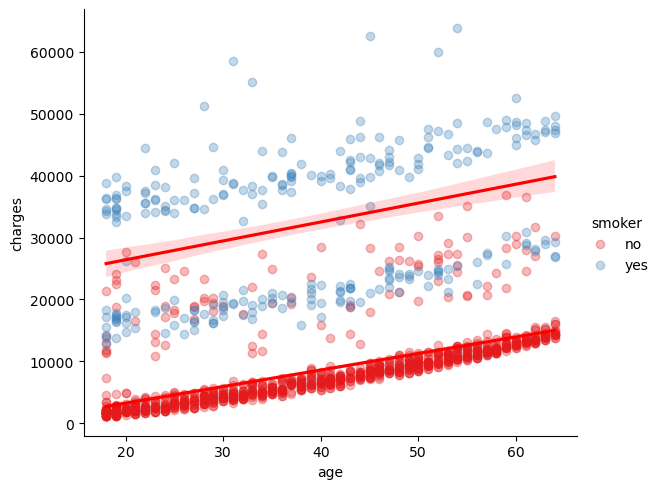

In [5]:
df_sort_age_ascending = df.sort_values("age", ascending=True)

print(df_sort_age_ascending.head())

sns.lmplot(data=df_sort_age_ascending, x="age", y="charges", hue="smoker", palette="Set1", height=5, aspect=1.2, scatter_kws={'alpha': 0.3}, line_kws={'color':'red'})

plt.show()
plt.close()

In [6]:
sexes_number = df["sex"].value_counts()

average_charge= df["charges"].mean()

exceed_average = df[df["charges"]>average_charge]

sexes_number_exceed  = exceed_average["sex"].value_counts()

smokers_number_exceed  = exceed_average["smoker"].value_counts()

     age  children     region Demographic Status
202   18         0  northeast         sex   male
799   18         3  southeast      smoker    yes
22    18         2  southeast         sex   male
368   18         1  northeast         sex   male
55    18         0  northeast         sex   male


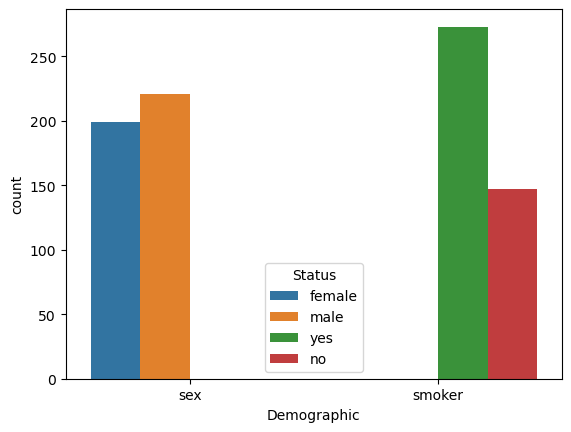

In [7]:
melted_exceed = pd.melt(
    frame=exceed_average,
    id_vars=["age", "children", "region"],
    value_vars=["sex", "smoker"],
    var_name="Demographic",
    value_name="Status"
)

sorted_melted_exceed= melted_exceed.sort_values(by="age", ascending=True)

print(sorted_melted_exceed.head())

grouped_exceed = sns.countplot(
    data=melted_exceed,
    x="Demographic",
    hue="Status"
)

plt.show()

plt.close()

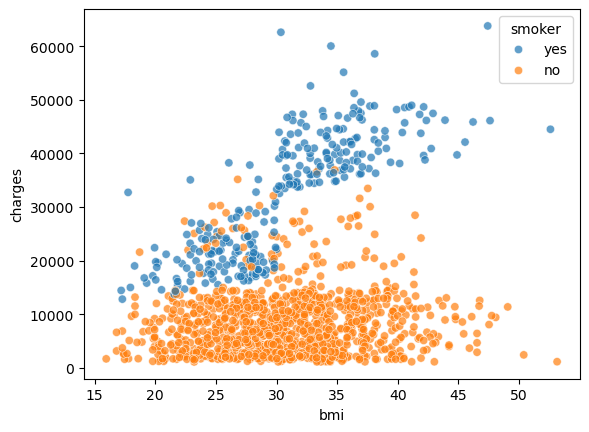

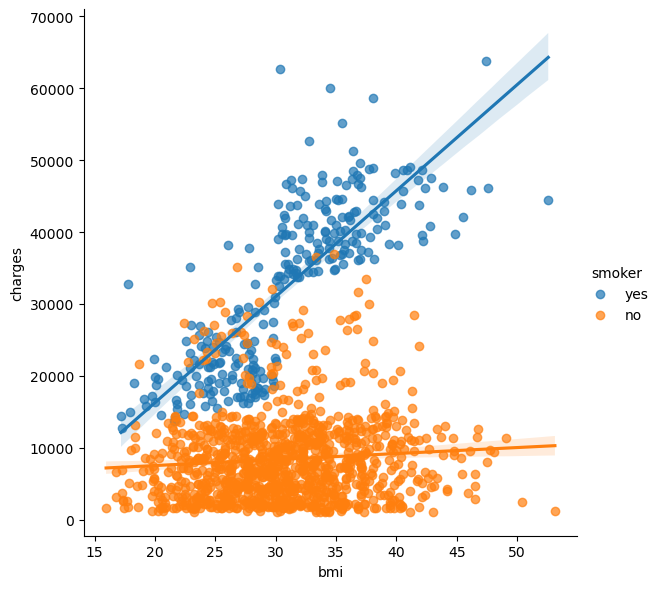

In [8]:
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7)

sns.lmplot(data=df, x="bmi", y="charges", hue="smoker", height=6, scatter_kws={'alpha':0.7})

plt.show()
plt.close()

In [9]:
age=df[["age"]]
charges=df["charges"]

age_model = LinearRegression()
age_model.fit(age.values,charges.values)

r_squared = age_model.score(age.values,charges.values)

print(f"R squared score: {r_squared:.4f}")

R squared score: 0.0894


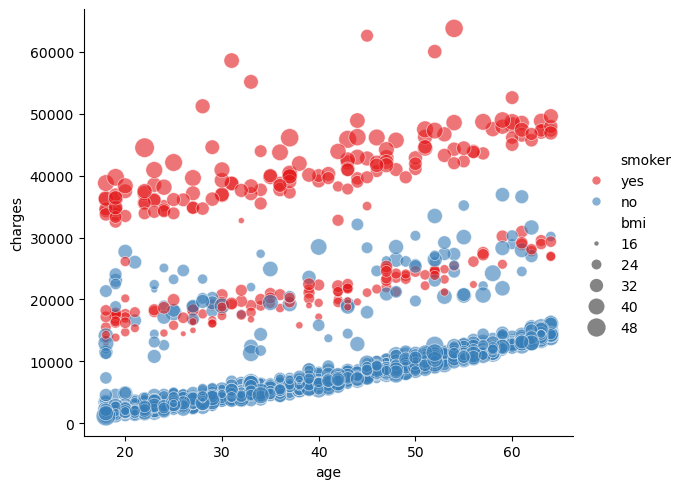

In [10]:
sns.relplot(data=df, x="age", y="charges", hue="smoker", size="bmi", sizes=(10,200), palette="Set1", alpha=0.6, height=5, aspect=1.2)

plt.show()
plt.close()

## Smokings affect on the correlation between charges and bmi

This section identifies the fact that smoking leads to an increased impact of bmi on a patients medical costs, suggesting that smoking acts as a risk multipler for other relevant factors. While bmi has a weak correlation 
coefficiant of 0.104305 for non smokers, for smokers it's 0.780249, drastically increasing the costs associated.

This was largely investigated due to an observation from the graph at the end of the previous section. The graph had higher bmi smokers concentrated almost exclusively in the highest cost band compared to non-smokers with 
higher bmis being spread between both the lower and middle band.

This shows how in order to create a full profile of the potential medical costs of a patient, the intersection of multiple conditions must be taken into account.

In [11]:
smokers = df[df["smoker"] == "yes"]
non_smokers = df[df["smoker"] == "no"]

smokers_bmi_correlation = smokers["bmi"].corr(smokers["charges"])

non_smokers_bmi_correlation = non_smokers["bmi"].corr(non_smokers["charges"])

print(smokers_bmi_correlation)
print(non_smokers_bmi_correlation)

0.8064806070155408
0.0840365431283327


In [12]:
smoker_median_cost=smokers["charges"].median()

print(smoker_median_cost)

34456.348450000005


In [13]:
df_tiers = df.copy()

df_tiers["cost_tier"] = np.where(df_tiers["charges"] > df_tiers.groupby("smoker")["charges"].transform("median"), 1, 0)

bmi_tiered_correlation = df_tiers.groupby("smoker")[["bmi", "cost_tier"]].corr().iloc[0::2,-1]

print(bmi_tiered_correlation)

smoker     
no      bmi    0.104305
yes     bmi    0.780249
Name: cost_tier, dtype: float64


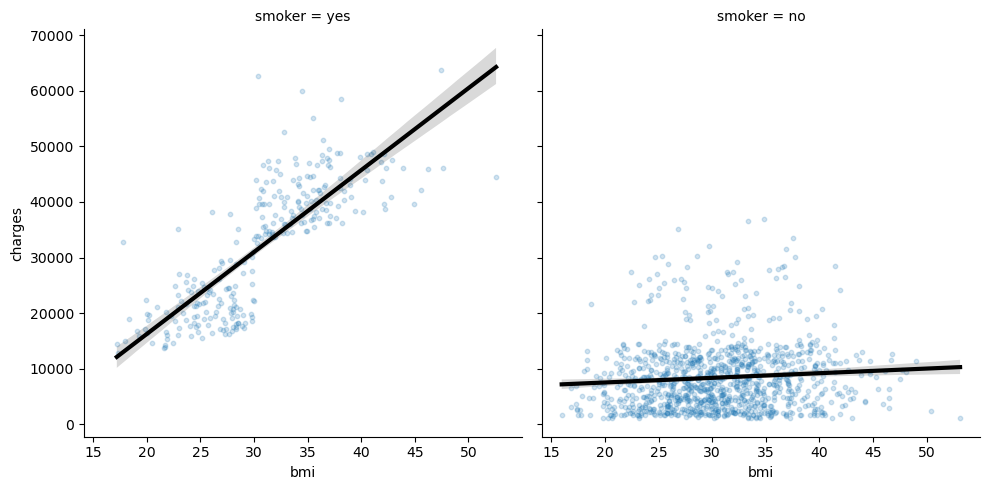

In [14]:
sns.lmplot(data=df_tiers, x="bmi", y="charges", col="smoker", scatter_kws={'alpha':0.2, "s":10}, line_kws={"linewidth":3, "color":"black"})

plt.show()
plt.close()

## Family size impact on charges, correlation with risk factors - chi-squared test

This section investigates how family size impacts the patient's medical charges. The initial boxplot shows a trend where the number of those with high bmi or who smoke decreases as the number of children increases.
This chart is to show the sample size for those with risk factors within the data set for each cohort being investigated, and how the sample size decreases as number of children increases, with a drastic drop between 3 and 4. 

This is then useful for the next chart, which shows the median and upper/lower quartile of the medical costs of each cohort. It shows an increasing trend in costs from 0 to 3, but this trend reverses at 4 and 5. 
The previous graph shows that the decreased sample size affects the trend observed, potentially having a differening distribution than to the samples of 0 to 3 children.

We can show how the cohorts of 4 and 5 children have differing distributions affecting the medical costs observed by showing the proportion of risk factors, which is shown in graph 3. It shows the proportion of patients
with risk factors is roughly 60%, until the cohort with 4 children, where it drops to 56% and lower, showing how 4 and 5 potentially have a different distribution, explaining the drop in medical costs in the second graph.

This hypothesis that the anomaly for 4 and 5 was caused by difference in distribution is disproved by use of a chi squared test at the end of this section. This shows that the difference in proportion of risk factors
is likely down to random chance, and not because having 4 or 5 children leads to a healthier lifestyle, showing how the low sample size of 4 and 5 leads to anomalous results during analysis. This represents a limitation of 
the dataset and likely the general population as a whole, as, anecdotally, having 4 or 5 children is rare compared to 1, 2, or 3. 

(In chart 1, the 0 children cohort has a vastly higher number of those with risk factors, compared to the others. This isn't suprising, the 0 cohort will naturally be the largest, as it's less a cohort about
having a specific number of children, and more about having children at all. This distinction, therefore, naturally explains its size in comparison to the other cohorts, and its relative normality in chart 3.)

In [15]:
df_children_size = df.copy()

df_children_size["High BMI (>=30)"] = df_children_size["bmi"] >= 30

df_children_size["Smoker"] = df_children_size["smoker"] == "yes"

In [16]:
children_melted = pd.melt(
    df_children_size,
    id_vars = ["children"],
    value_vars = ["High BMI (>=30)", "Smoker"],
    var_name = "Risk Factor",
    value_name = "Has Risk"
)

<Figure size 640x480 with 0 Axes>

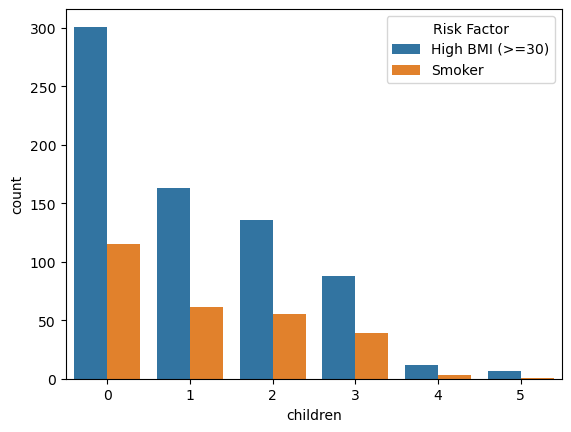

<Figure size 640x480 with 0 Axes>

In [17]:
sns.countplot(
    data=children_melted[children_melted["Has Risk"]==True],
    x="children",
    hue="Risk Factor"
)

plt.figure()

   children  Any Risk
0         0  0.618467
1         1  0.598765
2         2  0.654167
3         3  0.687898
4         4  0.560000
5         5  0.444444


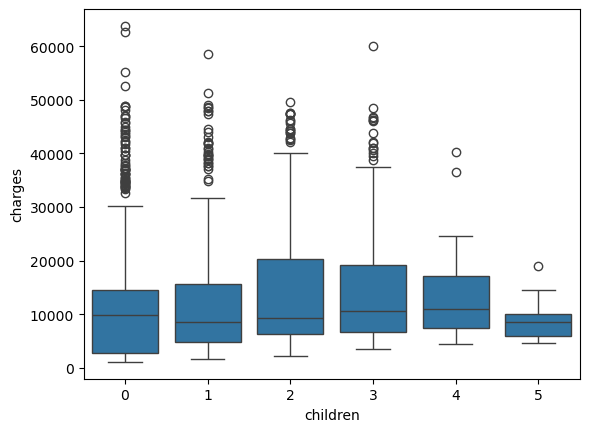

<Figure size 640x480 with 0 Axes>

In [18]:
sns.boxplot(data=df, x="children", y="charges")

plt.figure()

df_Risks = df_children_size.copy()

df_Risks["Any Risk"] = df_Risks["Smoker"] | df_Risks["High BMI (>=30)"]

risk_factor_sorted = df_Risks.groupby("children")["Any Risk"].mean().reset_index()

print(risk_factor_sorted)

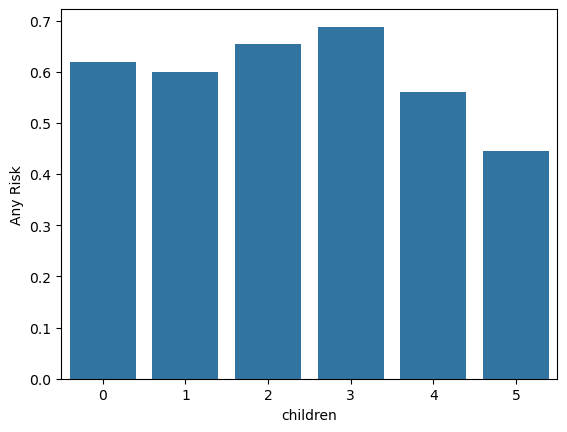

In [19]:
sns.barplot(
    data=risk_factor_sorted,
    x="children",
    y="Any Risk"
)

plt.show()

plt.close()

In [20]:
children_risk_cross_table = pd.crosstab(df_Risks["children"], df_Risks["Any Risk"])

print(children_risk_cross_table)

Any Risk  False  True 
children              
0           219    355
1           130    194
2            83    157
3            49    108
4            11     14
5            10      8


In [21]:
print(chi2_contingency(children_risk_cross_table))

Chi2ContingencyResult(statistic=np.float64(7.529858684489534), pvalue=np.float64(0.18412041263280587), dof=5, expected_freq=array([[215.35724963, 358.64275037],
       [121.56053812, 202.43946188],
       [ 90.04484305, 149.95515695],
       [ 58.90433483,  98.09566517],
       [  9.37967115,  15.62032885],
       [  6.75336323,  11.24663677]]))


In [22]:
chi2, p_value, dof, expected = chi2_contingency(children_risk_cross_table)

print(f"{chi2:.4f}, {p_value:.4f}")

7.5299, 0.1841


This section creates a machine learning model in order to predict the medical costs of a given patient, then later investigates how isolating the dataset into specific cohorts affects the accuracy of the models created by 
RandomForestRegressor. This then allows us to understand more about the underlying effects of the features of each patient, and the influence they have over their medical costs.

By specifically isolating smokers versus non-smokers, this lead to an r^2 of 0.87445 and 0.20328 respectively, compared to 0.82329 for the dataset as a whole. This shows how the accuracy of the model improves on a split cohort 
of smokers, but drastically decreases in accuracy for non-smokers. 

R^2 represents the variance in the model's answers that is explainable, and this increase in the smoker's cohort ties into the previous section, with smoking having an incredibly large effect on the medical costs of a patient, 
potentially being multiplicative. As this is a feature within the dataset, it is represented within the model's predictions.

This is in contrast to non-smokers, whose R^2 value drastically reduced, showing how the features within the dataset largely don't explain the medical costs of the cohort. The non-smokers cost could be explained by a multitude 
of factors not measured, such as exercise habits, diet, alcohol intake, and much more, however these are not represented within the dataset, and so not represented within the model's predictions.

This section could be seen as a way to represent how the features of a dataset can have a large effect upon the accuracy of any models trained upon it. With every feature potentially leading to a richer more accurate sense of 
each individual patient, allowing for better predictions.

Furthermore, regarding the MAE of each model, the smokers had a smaller value than for non-smokers (2253.08447 vs 2786.38231 to 4d.p). This shows how it is a more accurate estimate of each patient's medical costs, 
for potentially similar reasons as the R^2 value. As the effect of smoking is so large and dominant a determining factor for medical costs, that the model is more easily able to predict them, compared to non-smokers, which 
don't have the presence of a similar single dominant feature. As such, the model is unable to find the underlying structure of the cohort, leading to the values for the model being more likely to cluster around the mean, 
leading to a larger MAE.

During my investigation, I first used a standard split, but then switched to a k-fold method. This splits the data 5 separate sections, or "folds", using each one as the testing set once. This led to a difference in the 
values obtained for each cohort, with my original values being referenced earlier in the summary. However, my new values are quite interesting, with MAE increasing to 2347.97 and 2826.81, and r^2 changing to 0.84995 and 0.27178 
for smokers and non-smokers respectively. This is surprising, as the average error increased, suggesting that the models got less accurate, but for non-smokers, the r^2 increased drastically, leading to more of the variance 
being explained than before. 

This is largely due to the smokers model being somewhat "lucky" with the draw of the tests splits, leading to more desirable results for the model. The K-fold method reduces the effect of chance within the shuffling of data, 
leading to a more realistic reflection of how the model would have actually performed. This can be seen by looking specifically at the results per split, for example split 4 vs 5 for smokers (MAE 1813.56 vs 3058.75 and r^2 
0.9097 vs 0.7681), which can show a high degree of difference compared to the average, showing how chance within testing splits can show a large role in the results and thus the perceived accuracy of a model. 
The repeated shuffling, testing, then averaging prevented this, leading to a better view of the model's efficacy and therefore a potentially better conclusion on how the cohort separation should be viewed.

Thinking about how the model worked, I asked myself how the LinearRegression used earlier would perform. Modifying my function for this, the LinearRegression model performed worse for the full dataset than the Forest 
(MAE 4199.32 vs 2754.00, r^2 0.83522 vs 0.74570). However, the Linear Regression model performed surprisingly well for non-smokers (MAE 2826.81 vs 2515.06, r^2 0.27178 vs 0.40973). This is likely due to similar logic as the 
R^2 values, with the lack of the dominant feature of smoking leading to non-smokers medical costs being largely determined by bmi or aging, rather than an interaction of factors, lending itself better to the linear regression
model rather than the more complex random forest regressor.

In [23]:
def model_maker(given_dataset, dataset_name="Dataset"):
    patients_one_hot = pd.get_dummies(given_dataset)

    machine_answers = patients_one_hot["charges"]

    machine_input = patients_one_hot.drop(columns=["charges"])

    forest_model = RandomForestRegressor(random_state=12)

    linear_model =  LinearRegression()

    kf=KFold(n_splits=5, shuffle=True, random_state=12)

    fr_fold_mae = []
    fr_fold_r2 = []

    lr_fold_mae = []
    lr_fold_r2 = []

    for fold, (train_index, test_index) in enumerate(kf.split(machine_input)):

        input_train = machine_input.iloc[train_index]
        input_test = machine_input.iloc[test_index]
        answers_train = machine_answers.iloc[train_index]
        answers_test = machine_answers.iloc[test_index]

        forest_model.fit(input_train, answers_train)

        linear_model.fit(input_train, answers_train)

        fr_model_predictions = forest_model.predict(input_test)

        lr_model_predictions = linear_model.predict(input_test)

        fr_mae = mean_absolute_error(answers_test, fr_model_predictions)

        lr_mae = mean_absolute_error(answers_test, lr_model_predictions)

        fr_r2 = r2_score(answers_test, fr_model_predictions)

        lr_r2 = r2_score(answers_test, lr_model_predictions)

        fr_fold_mae.append(fr_mae)

        fr_fold_r2.append(fr_r2)

        lr_fold_mae.append(lr_mae)

        lr_fold_r2.append(lr_r2)

        print(f"\nFold {fold + 1} - Forest MAE: ${fr_mae:.2f}, Forest R²: {fr_r2:.4f}")

        print(f"Fold {fold + 1} - Linear MAE: ${lr_mae:.2f}, Linear R²: {lr_r2:.4f}")

    fr_average_mae = np.mean(fr_fold_mae)

    fr_average_r2 = np.mean(fr_fold_r2)

    lr_average_mae = np.mean(lr_fold_mae)

    lr_average_r2 = np.mean(lr_fold_r2)

    print(f"\nSummary for {dataset_name}:")
    print(f"Forest average MAE : ${fr_average_mae:.2f}")
    print(f"Forest average R^2 : {fr_average_r2:.5f}")  
    print(f"Linear average MAE : ${lr_average_mae:.2f}")
    print(f"Linear average R^2 : {lr_average_r2:.5f}")  

In [24]:
smoker_df = df[df["smoker"] == "yes"]

non_smoker_df = df[df["smoker"] == "no"]

In [25]:
model_maker(df, "Full Dataset")


Fold 1 - Forest MAE: $2747.91, Forest R²: 0.8220
Fold 1 - Linear MAE: $4319.45, Linear R²: 0.7100

Fold 2 - Forest MAE: $2718.61, Forest R²: 0.8335
Fold 2 - Linear MAE: $4139.86, Linear R²: 0.7416

Fold 3 - Forest MAE: $2714.26, Forest R²: 0.8661
Fold 3 - Linear MAE: $4152.53, Linear R²: 0.7910

Fold 4 - Forest MAE: $2801.78, Forest R²: 0.8253
Fold 4 - Linear MAE: $4230.03, Linear R²: 0.7290

Fold 5 - Forest MAE: $2787.45, Forest R²: 0.8293
Fold 5 - Linear MAE: $4154.73, Linear R²: 0.7569

Summary for Full Dataset:
Forest average MAE : $2754.00
Forest average R^2 : 0.83522
Linear average MAE : $4199.32
Linear average R^2 : 0.74570


In [26]:
model_maker(smoker_df, "Smokers")


Fold 1 - Forest MAE: $2269.07, Forest R²: 0.8715
Fold 1 - Linear MAE: $4514.30, Linear R²: 0.7430

Fold 2 - Forest MAE: $2186.72, Forest R²: 0.8585
Fold 2 - Linear MAE: $4558.84, Linear R²: 0.7044

Fold 3 - Forest MAE: $2411.74, Forest R²: 0.8419
Fold 3 - Linear MAE: $3915.00, Linear R²: 0.7516

Fold 4 - Forest MAE: $1813.56, Forest R²: 0.9097
Fold 4 - Linear MAE: $4903.21, Linear R²: 0.7465

Fold 5 - Forest MAE: $3058.75, Forest R²: 0.7681
Fold 5 - Linear MAE: $4778.55, Linear R²: 0.7503

Summary for Smokers:
Forest average MAE : $2347.97
Forest average R^2 : 0.84995
Linear average MAE : $4533.98
Linear average R^2 : 0.73916


In [27]:
model_maker(non_smoker_df, "Non-smokers")


Fold 1 - Forest MAE: $2834.12, Forest R²: 0.1833
Fold 1 - Linear MAE: $2528.63, Linear R²: 0.3180

Fold 2 - Forest MAE: $2677.15, Forest R²: 0.3548
Fold 2 - Linear MAE: $2560.94, Linear R²: 0.4520

Fold 3 - Forest MAE: $2565.71, Forest R²: 0.3118
Fold 3 - Linear MAE: $2305.25, Linear R²: 0.5237

Fold 4 - Forest MAE: $2940.99, Forest R²: 0.2408
Fold 4 - Linear MAE: $2661.75, Linear R²: 0.3358

Fold 5 - Forest MAE: $3116.06, Forest R²: 0.2682
Fold 5 - Linear MAE: $2518.73, Linear R²: 0.4192

Summary for Non-smokers:
Forest average MAE : $2826.81
Forest average R^2 : 0.27178
Linear average MAE : $2515.06
Linear average R^2 : 0.40973


Reflecting on this project as a whole, when attempting to understand a dataset, dividing it into specific cohorts is incredibly important. By using sampling methods that reduce the effect of chance, in this case through 
use of K-folds, the models are also able to be more realistic and give a better view of how the model being trained performs. This allows for deeper analysis, and more accurate models for predicting specific
values associated with interacting features. Understanding the ways in which these features interact allows for usage of more suitable models for each cohort, learning that knowledge of the underlying data informs the best choice.
Knowing whether a specific feature acts as a multiplying factor or acts linearly aids greatly in choosing the complexity of a model, potentially allowing for vastly reduced average errors and superior predictions for models.
Finally, the consideration of these aspects also highlights the importance of measuring many relevant features, reducing the variance that is left unexplained by the models, leading to increased r^2 values. Taking these lessons
into account, we can have a vastly superior understanding of a dataset, leading to better predictions.       